In [2]:
from braket.circuits import Circuit
from braket.devices import LocalSimulator
from braket.aws import AwsDevice
from braket.circuits import Observable


In [3]:
import pandas as pd
import numpy as np


In [4]:
device = AwsDevice("arn:aws:braket:::device/quantum-simulator/amazon/sv1")

In [2427]:
device = LocalSimulator()

In [2241]:
device = AwsDevice("arn:aws:braket:::device/quantum-simulator/amazon/dm1")

In [288]:
import numpy as np

def edge_index_to_adjacency_matrix(edge_index, num_nodes):
    """
    Convert edge index representation to an adjacency matrix.

    Parameters:
        edge_index (numpy array): Edge index representation of the graph.
                                  Each column represents an edge.
                                  Shape: (2, num_edges), where num_edges is the number of edges.
        num_nodes (int): Number of nodes in the graph.


    Returns:
        numpy array: Adjacency matrix representing the graph.
                     Shape: (num_nodes, num_nodes).
    """
    adjacency_matrix = np.zeros((num_nodes, num_nodes), dtype=int)
    for i in range(edge_index.shape[1]):
        src_node = edge_index[0, i]
        dest_node = edge_index[1, i]
        adjacency_matrix[src_node, dest_node] = 1
        adjacency_matrix[dest_node, src_node] = 1  # If graph is undirected, uncomment this line
    return adjacency_matrix

# Example usage:
edge_index = np.array([[0, 1, 1, 2,2,1],
                       [1, 0, 2, 1,2,0]])  # Example edge index representation
num_nodes = 3  # Example number of nodes
adj_matrix = edge_index_to_adjacency_matrix(edge_index, num_nodes)
#print("Adjacency Matrix:")
#print(adj_matrix)


In [5]:
adj_matrix = np.array([[0,0,1,0,1],[1,1,0,1,1],[0,1,0,0,1],[1,0,1,0,0],[0,1,0,1,0],[0,0,1,0,1],[1,1,0,1,1],[0,1,0,0,1],[1,0,1,0,0],[1,0,1,0,0]])

In [6]:
#theta = 0.92
def initiate1(theta):
    #Initialization circuit
    #theta1 = 0
    crt = Circuit()
    for i in range(len(adj_matrix)):
        crt.h(i)
   # theta1 = theta
    #theta = theta
    unitary_matrix = np.array([[np.cos(theta), -np.sin(theta)],
                           [np.sin(theta), np.cos(theta)]])
       # unitary_gate = UnitaryGate(unitary_matrix)
    for i in range(len(adj_matrix)):
        crt.unitary(matrix = unitary_matrix,targets = [i])
    #result = device.run(crt, shots=1000).result()
    

    #Creating Rotational gates
    crt1 = Circuit()
    P = theta#np.random.uniform(0.5,1)
    #X = np.array([[1,1,0,0,1],[1,0,1,1,0],[0,0,1,0,1],[0,1,0,1,1],[0,1,0,1,1]])
    X = np.array([[-0.7177142924990434, 0.07845441560938655],
  [-0.8927286917484196, 0.03545177705393221],
  [-0.6302235247817874, 0.24321614785139828],
  [-0.9456034564263938, 0.16793976954463666],
  [-0.8242083370102109, 0.2666268847132241],
                  [0.062224871157863515, 1.4214365706716727],
                  [-0.1276572659331247, 0.7881927932030084],
                  [0.7596895148300062, 0.4004133580645298],
                  [-0.7177142924990434, 0.07845441560938655],
  [-0.8927286917484196, 0.03545177705393221]
                 
                 
                 
                 ])
    for i in range(len(adj_matrix)):
        theta = X[i]*P
        for j in range(2): 
       # crt1.rx(i,theta[j])
            #crt1.rx(i,theta[j])
            crt1.ry(i,theta[j])
            #crt1.rz(i,theta[j])
    
    #Creating entanglement
    for i in range(len(adj_matrix)):
        for j in range(i,len(adj_matrix)):
            if i != j:
           # print(i,j)
                crt1.cnot(i,j)
    crt3 = crt +crt1
    #Creating observable gates
    for i in range(len(adj_matrix)):
        crt3.probability(target = i)
        crt3.expectation(observable=Observable.Z(), target=i)
        crt3.variance(observable=Observable.Z(), target=i)
    #print(crt3)
    return crt3

In [7]:
#Running circuit and parameter running
def cir_exec(theta):
    #print(theta)
    theta1 = theta
    import numpy as np
    crt3 = initiate1(theta) 
    result = device.run(crt3,shots =10000).result()
    #print(result.measurement_probabilities)
    
    mean = []
    cov_mat = []
    i = 1
    j = 2
    while i< len(result.values):
        mean.append(result.values[i])
        cov_mat.append(result.values[j])
        i+=3
        j+=3
    #print(mean, cov_mat)
    mean = np.array(mean)
    cov_mat = np.array(cov_mat)
    
    # Latent space Z sampling
    import numpy as np
    A = len(adj_matrix)
    Z = []
#mean = np.array([-0.99,0.98,0.979]) # Mean vector

#cov_mat = np.array([0.01915,0.03799,0.03963]) # Covariance matrix

# Generate samples from latent space
    num_samples = 3
    for i in range(len(adj_matrix)):
        ep = np.random.normal(0,1)
        Z_i = mean + cov_mat*ep
        Z_i = Z_i.tolist()
        #print(Z_i)
        Z.append(Z_i)
        
    cov_mat = [[cov_mat[0],0,0,0,0,0,0,0,0,0],[0,cov_mat[1],0,0,0,0,0,0,0,0],[0,0,cov_mat[2],0,0,0,0,0,0,0],[0,0,0,cov_mat[3],0,0,0,0,0,0],[0,0,0,0,cov_mat[4],0,0,0,0,0],
              [0,0,0,0,0,cov_mat[5],0,0,0,0],[0,0,0,0,0,0,cov_mat[6],0,0,0],[0,0,0,0,0,0,0,cov_mat[7],0,0],[0,0,0,0,0,0,0,0,cov_mat[8],0],[0,0,0,0,0,0,0,0,0,cov_mat[9]]]
    #for i in range(len(adj_matrix)):
    Z = np.random.multivariate_normal(mean, cov_mat,size =len(adj_matrix))
    
    #Code for decoder (logistic sigmoid based decoder)
    k = 0
    auc = []
    auc1 = []
    prob = 1
    log_prob = 0
    for i in adj_matrix:
        l= 0
        for j in i:
            if j ==1:
                prob = Sigmoid(np.dot(Z[k],Z[l]))
                log_prob = log_prob + np.log(Sigmoid(np.dot(Z[k],Z[l])))
                auc.append(prob)
                #print(log_prob)
                #print("prob",prob)
                #print("Indivial probabilities in adj-matrix elements",Sigmoid(np.dot(Z[k],Z[l])))
                l += 1 
            else:
                l +=1
                prob = 1- Sigmoid(np.dot(Z[k],Z[l]))
                auc.append(prob)
                 
        k+=1
        auc1.append(auc)
        #print(auc)
    #Decoder probability
    print("Decoder decoding probability -", prob) 
    print(log_prob)    
    # Loss calculation
    
    return theta1,log_prob,prob,auc

In [8]:
def para_update(theta,log_prob,prob,auc):
    alpha = 0.01
    theta = theta + alpha*log_prob
    print(theta)
    return theta,auc
    # for i in range(epoch):
    #     epoch = epoch -1
    #     cir_exec(theta,epoch)

In [9]:
theta = 0.5

In [12]:
prob_list = []
for i in range(10):
    #theta1,log_prob,prob = (cir_exec(theta))
    #prob_list.append(prob)
    theta,auc = para_update(*cir_exec(theta))
     


Decoder decoding probability - 0.00415744632654047
-3.041148525951361
0.4695885147404864
Decoder decoding probability - 0.2145003085648346
-3.826640889457881
0.4313221058459076
Decoder decoding probability - 0.008037245002796678
-3.7009304504749663
0.3943128013411579
Decoder decoding probability - 0.024054353345017043
-12.93746476306278
0.2649381537105301
Decoder decoding probability - 0.049136328385867345
-18.47509719380057
0.0801871817725244
Decoder decoding probability - 0.39589906673041153
-30.427367798366852
-0.2240864962111441
Decoder decoding probability - 0.6441680780971661
-19.667090601849
-0.4207574022296341
Decoder decoding probability - 0.29100580474340076
-17.848578092107932
-0.5992431831507135
Decoder decoding probability - 0.047837524104610396
-0.9200163246708665
-0.6084433463974221
Decoder decoding probability - 0.008686674922718463
-1.559138935435979
-0.6240347357517819


In [11]:
def Sigmoid(x):
    return 1/(1+np.exp(-x))

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50]


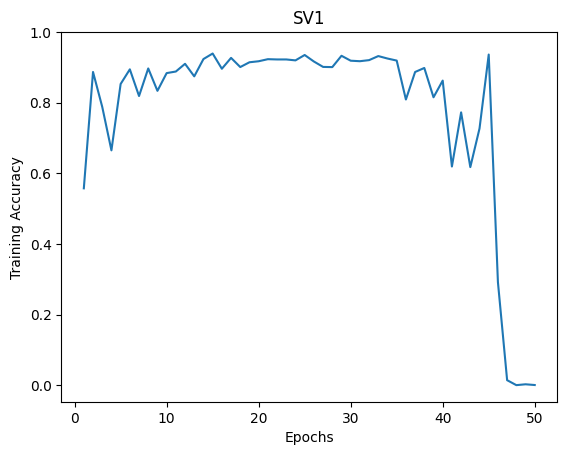

In [2313]:
accu_train3 = prob_list#[0.423,0.633,0.87782,0.862,0.6582]
#accu_train4 = [0.1376,0.448,0.63509,0.88,0.8841]
p_plotting(accu_train3,"Training Accuracy","SV1")

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]


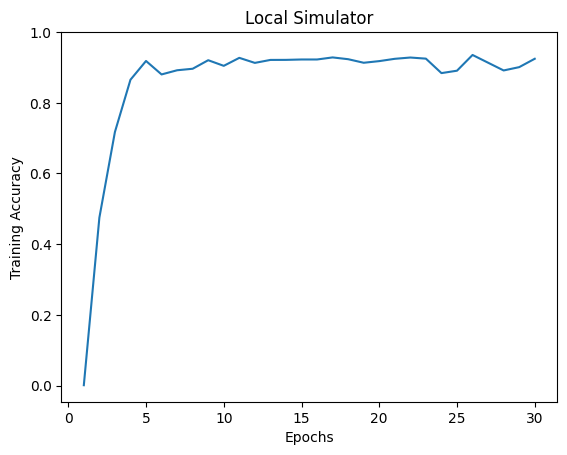

In [2320]:
accu_train3 = prob_list#[0.423,0.633,0.87782,0.862,0.6582]
#accu_train4 = [0.1376,0.448,0.63509,0.88,0.8841]
p_plotting(accu_train3,"Training Accuracy","Local Simulator")

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35]


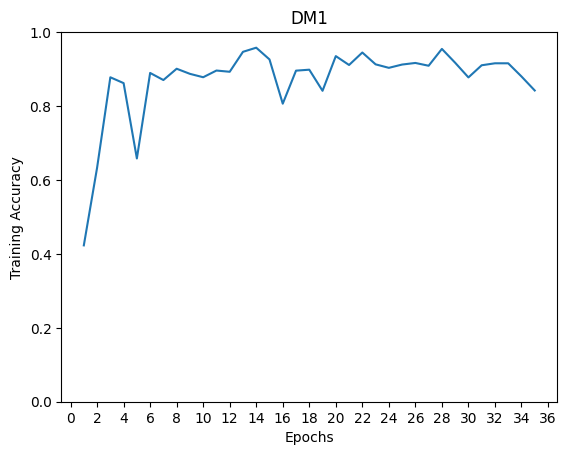

In [2250]:
accu_train3 = [0.423,0.633,0.87782,0.862,0.6582]
accu_train3 = accu_train3+prob_list
#accu_train4 = [0.1376,0.448,0.63509,0.88,0.8841]
p_plotting(accu_train3,"Training Accuracy","DM1")

In [2277]:
import matplotlib.pyplot as plt
import numpy as np
def p_plotting(a,c,d):
    x = []
    ypoints = a
    for i in range(len(a)):
        x.append(i+1)
    plt.plot(x,ypoints)
    print(x)
    #plt.plot(x,b)#, linestyle = 'line')
    plt.xlabel("Epochs")
    plt.ylabel(c)
   # plt.legend(["Sample size = 3","Sample size = 4"])
   # plt.xticks(np.arange(0, 102, 2))
    plt.yticks(np.arange(0, 1.2, 0.2))
    plt.title(d)
    plt.show()

In [2188]:
from statistics import mean
avg = mean(prob_list)

In [2189]:
avg

0.8432245082272883

In [16]:
from sklearn.metrics import roc_auc_score
import numpy as np

# Example ground truth labels and predicted probabilities
y_true = adj#np.array([[0,0,1,0,1],[1,1,0,1,1],[0,1,0,0,1],[1,0,1,0,0],[0,1,0,1,0],[0,0,1,0,1],[1,1,0,1,1],[0,1,0,0,1],[1,0,1,0,0],[1,0,1,0,0]])
y_scores = np.array(auc)
auc = roc_auc_score(y_true, y_scores)
print("AUC:", auc)


AUC: 1.0


In [15]:
adj = adj_matrix.flatten()

In [2505]:
adj

array([0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 1, 0, 0])

In [13]:
auc

[0.02604117532032657,
 0.0009999122233502744,
 0.9990000877766497,
 0.003049461057510028,
 0.99695053894249,
 0.9739588246796734,
 0.9999791579573372,
 0.0008332597407754161,
 0.9991667402592246,
 0.5738026525813894,
 0.0007686519754480647,
 0.9992313480245519,
 0.0034869060806329566,
 0.04142494690396037,
 0.9585750530960396,
 0.9498985231138071,
 0.0034869060806329566,
 0.996513093919367,
 0.17319873864926139,
 0.05326986444729798,
 0.4261973474186106,
 0.5738026525813894,
 0.17319873864926139,
 0.8268012613507386,
 0.02097724632565734,
 0.00791875421907573,
 0.009520996322716524,
 0.9904790036772835,
 0.02097724632565734,
 0.9790227536743427,
 0.9963989634602451,
 0.9993781637337131,
 0.00246124589401997,
 0.99753875410598,
 0.9806013659362589,
 0.0008643135274507552,
 0.9991356864725492,
 0.0002759576417015186,
 0.0014494604375389075,
 0.9985505395624611,
 0.9935612467114441,
 0.008791432814478584,
 0.9912085671855214,
 0.09065748794983497,
 0.009140730036652611,
 0.963245831147290